# Phase 1, Experiment 1.2 — Two-stage hurdle model

Stage 1 predicts P(played_any = 1) from pre-kickoff features. Stage 2 predicts E[total_points | played_any = 1], trained only on rows where the player actually got on the pitch. Final prediction is the product, applied to all val rows.

Stage 1 candidates: logistic regression (primary linear baseline) and SVM-RBF (course requirement, fit on a 10k stratified subsample for tractability). Pick the better. Stage 2 is Ridge with alpha re-tuned on the played-only subset — different variance structure than the full train set, no reason to assume α=1 from 1.1 transfers.

Headline metric is combined R² on full val, directly comparable to 1.1's flat Ridge (R² = 0.599). Stage-1 and stage-2 metrics are reported separately for diagnosis.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score, roc_auc_score, accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd()))
from src.config import PROCESSED_PATH, get_feature_group, get_splits

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(PROCESSED_PATH)
train_mask, val_mask, test_mask = get_splits(df)

y_train = df.loc[train_mask, "total_points"].values
y_val = df.loc[val_mask, "total_points"].values
val_positions = df.loc[val_mask, "position"].values

# Helpers (copied from 1.1 — will graduate to src/ after 1.3)
def feature_columns(groups):
    cols = []
    for g in groups:
        cols.extend(get_feature_group(g))
    return cols


def build_X(df, mask, cols, scaler=None):
    X = df.loc[mask, cols].values
    if scaler is None:
        scaler = StandardScaler().fit(X)
    return scaler.transform(X), scaler


def evaluate(y_true, y_pred, positions=None):
    out = {"r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred)}
    if positions is not None:
        for pos in ["GK", "DEF", "MID", "FWD"]:
            m = positions == pos
            if m.sum():
                out[f"mae_{pos}"] = mean_absolute_error(y_true[m], y_pred[m])
    return out

## Stage-1 and Stage-2 setup

Same feature set as the 1.1 flat baseline: `BASE_PREKICKOFF + POSITION + XP + ICT_BLOCK + OTHER_LAGS` (no CLUSTER). Two scalers are fit: one on the full train (for stage 1, which sees all rows) and one on the played-only train subset (for stage 2, which only sees rows where the player got minutes). At inference, the val matrix gets transformed by both scalers — stage 1 uses its scaler, stage 2 uses its scaler — and predictions are multiplied.

In [3]:
GROUPS = ["BASE_PREKICKOFF", "POSITION", "XP", "ICT_BLOCK", "OTHER_LAGS"]
cols = feature_columns(GROUPS)

# Stage 1 (full train)
X_train_s1, scaler_s1 = build_X(df, train_mask, cols)
X_val_s1, _ = build_X(df, val_mask, cols, scaler=scaler_s1)
y_train_play = df.loc[train_mask, "played_any"].values
y_val_play = df.loc[val_mask, "played_any"].values

# Stage 2 (played-only train; full val matrix transformed with stage-2 scaler for inference)
played_train_mask = train_mask & (df["played_any"] == 1)
played_val_mask = val_mask & (df["played_any"] == 1)

X_train_s2, scaler_s2 = build_X(df, played_train_mask, cols)
X_val_s2_played, _ = build_X(df, played_val_mask, cols, scaler=scaler_s2)
X_val_s2_full, _ = build_X(df, val_mask, cols, scaler=scaler_s2)

y_train_played_pts = df.loc[played_train_mask, "total_points"].values
y_val_played_pts = df.loc[played_val_mask, "total_points"].values

# Sanity: played-any rate by position (validates that 'played_any' is the right structural-zero cut)
play_rate_train = (
    df.loc[train_mask].groupby("position")["played_any"].mean()
    .reindex(["GK", "DEF", "MID", "FWD"])
)
play_rate_val = (
    df.loc[val_mask].groupby("position")["played_any"].mean()
    .reindex(["GK", "DEF", "MID", "FWD"])
)
print(f"played_any rate — train: {y_train_play.mean():.3f}   val: {y_val_play.mean():.3f}")
print("\nplayed_any rate by position:")
print(pd.DataFrame({"train": play_rate_train, "val": play_rate_val}))

played_any rate — train: 0.426   val: 0.389

played_any rate by position:
          train    val
position              
GK       0.2706 0.2303
DEF      0.4205 0.4058
MID      0.4643 0.4198
FWD      0.4484 0.3813


## Stage 1a: Logistic regression

Default C=1, max_iter=2000. Calibration is the metric that matters most for the hurdle product — Brier score and the reliability diagram check whether `predict_proba` is producing actual probabilities or just rank-ordering.

In [4]:
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_s1, y_train_play)

p_play_lr = lr.predict_proba(X_val_s1)[:, 1]
y_play_pred_lr = (p_play_lr >= 0.5).astype(int)

lr_metrics = {
    "auc": roc_auc_score(y_val_play, p_play_lr),
    "accuracy": accuracy_score(y_val_play, y_play_pred_lr),
    "brier": brier_score_loss(y_val_play, p_play_lr),
}
print("Logistic regression (stage 1):")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.4f}")

Logistic regression (stage 1):
  auc: 0.9466
  accuracy: 0.8826
  brier: 0.0863


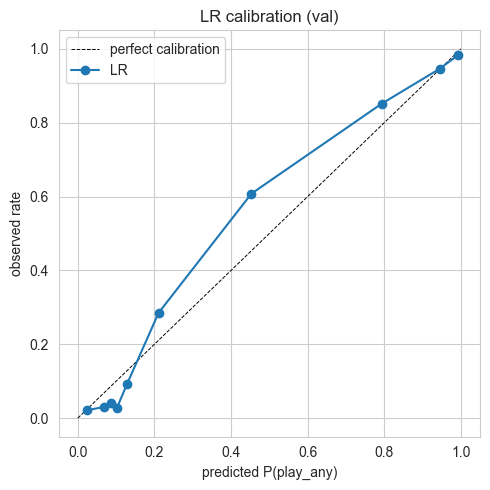

In [5]:
# Reliability diagram for LR
prob_true, prob_pred = calibration_curve(y_val_play, p_play_lr, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.7, label="perfect calibration")
ax.plot(prob_pred, prob_true, marker="o", label="LR")
ax.set_xlabel("predicted P(play_any)")
ax.set_ylabel("observed rate")
ax.set_title("LR calibration (val)")
ax.legend()
plt.tight_layout()
plt.show()

## Stage 1b: SVM-RBF on 10k stratified subsample

`probability=True` adds an internal 5-fold CV pass for Platt scaling (so the multiplicative product step is meaningful). On 10k rows this should fit in a few minutes — we time it. Default C=1, gamma='scale'. We did not tune SVM hyperparameters because the wall-clock cost on full train with `probability=True` was prohibitive — this is a bounded comparison against LR, not an optimization.

In [6]:
SVM_SAMPLE_SIZE = 10_000

idx_sub, _ = train_test_split(
    np.arange(len(y_train_play)),
    train_size=SVM_SAMPLE_SIZE,
    stratify=y_train_play,
    random_state=RANDOM_STATE,
)
X_train_sub = X_train_s1[idx_sub]
y_train_sub = y_train_play[idx_sub]
print(f"subsample size: {len(idx_sub):,}   played rate: {y_train_sub.mean():.3f}")

svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
t0 = time.time()
svm.fit(X_train_sub, y_train_sub)
fit_time = time.time() - t0
print(f"SVM fit time: {fit_time:.1f}s")

p_play_svm = svm.predict_proba(X_val_s1)[:, 1]
y_play_pred_svm = (p_play_svm >= 0.5).astype(int)

svm_metrics = {
    "auc": roc_auc_score(y_val_play, p_play_svm),
    "accuracy": accuracy_score(y_val_play, y_play_pred_svm),
    "brier": brier_score_loss(y_val_play, p_play_svm),
}
print("\nSVM-RBF (stage 1, 10k subsample):")
for k, v in svm_metrics.items():
    print(f"  {k}: {v:.4f}")

subsample size: 10,000   played rate: 0.426
SVM fit time: 7.0s

SVM-RBF (stage 1, 10k subsample):
  auc: 0.9443
  accuracy: 0.8895
  brier: 0.0849


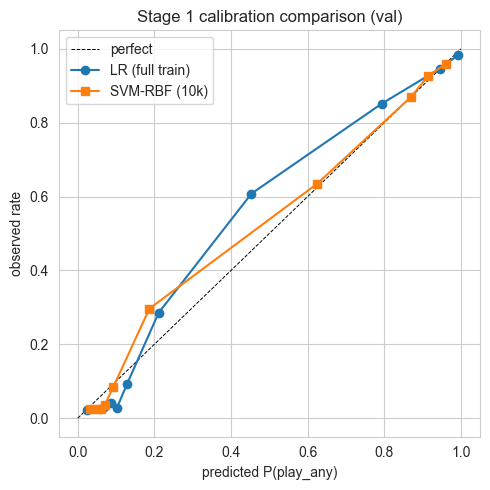

In [7]:
# Reliability for both — overlay
prob_true_svm, prob_pred_svm = calibration_curve(y_val_play, p_play_svm, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.7, label="perfect")
ax.plot(prob_pred, prob_true, marker="o", label="LR (full train)")
ax.plot(prob_pred_svm, prob_true_svm, marker="s", label="SVM-RBF (10k)")
ax.set_xlabel("predicted P(play_any)")
ax.set_ylabel("observed rate")
ax.set_title("Stage 1 calibration comparison (val)")
ax.legend()
plt.tight_layout()
plt.show()

## Pick stage-1 winner

If the metrics are within noise (AUC differing by <0.005, Brier within 0.002), keep LR — full train, calibrated by construction, faster to retrain in Phase 2. If SVM meaningfully wins, switch to SVM and document the subsample-size caveat.

In [8]:
s1_compare = pd.DataFrame({"LR": lr_metrics, "SVM-RBF (10k)": svm_metrics}).T
print(s1_compare)

# Decision: prefer LR unless SVM AUC > LR AUC + 0.005 AND SVM Brier < LR Brier
svm_better = (svm_metrics["auc"] > lr_metrics["auc"] + 0.005) and (svm_metrics["brier"] < lr_metrics["brier"])
if svm_better:
    p_play_val = p_play_svm
    stage1_name = "SVM-RBF (10k)"
else:
    p_play_val = p_play_lr
    stage1_name = "LR"
print(f"\nstage 1 selected: {stage1_name}")

                 auc  accuracy  brier
LR            0.9466    0.8826 0.0863
SVM-RBF (10k) 0.9443    0.8895 0.0849

stage 1 selected: LR


## Stage 2: Ridge regressor on played-only subset

Re-sweep Ridge alpha on the played-only train; the variance structure here (no DNPs) differs from 1.1's full-train fit, so reusing α=1 reflexively isn't justified. Standalone metrics report stage 2 in isolation — R² and MAE on played-only val rows. This is the apples-to-apples score for stage 2; the combined hurdle metric comes later.

In [9]:
RIDGE_ALPHAS = [1e-4, 1e-2, 1, 100, 1e4, 1e6]

s2_rows = []
for a in RIDGE_ALPHAS:
    m = Ridge(alpha=a).fit(X_train_s2, y_train_played_pts)
    pred = m.predict(X_val_s2_played)
    s2_rows.append({
        "alpha": a,
        "r2": r2_score(y_val_played_pts, pred),
        "mae": mean_absolute_error(y_val_played_pts, pred),
    })
s2_sweep = pd.DataFrame(s2_rows)
print("Stage 2 — played-only val:")
print(s2_sweep.to_string(index=False))

best_s2_alpha = s2_sweep.loc[s2_sweep["r2"].idxmax(), "alpha"]
ridge_s2 = Ridge(alpha=best_s2_alpha).fit(X_train_s2, y_train_played_pts)
print(f"\nbest stage-2 alpha: {best_s2_alpha:g}")

Stage 2 — played-only val:
       alpha     r2    mae
      0.0001 0.4947 1.5463
      0.0100 0.4947 1.5463
      1.0000 0.4947 1.5462
    100.0000 0.4932 1.5481
  10000.0000 0.3469 1.7586
1000000.0000 0.0248 2.2788

best stage-2 alpha: 1


## Combined hurdle prediction on full val

`pred = P(play) × E[points | play]` applied to every val row, including DNPs. Stage 2 may produce nonsensical scores for DNP-like rows since it never trained on them, but the multiplication by low P(play) downweights those. Headline R² and MAE are computed on the full val set — directly comparable to 1.1.

In [10]:
e_pts_val_full = ridge_s2.predict(X_val_s2_full)
pred_hurdle = p_play_val * e_pts_val_full

hurdle_metrics = evaluate(y_val, pred_hurdle, val_positions)
print("Hurdle (combined, full val):")
for k, v in hurdle_metrics.items():
    print(f"  {k}: {v:.4f}")

Hurdle (combined, full val):
  r2: 0.6386
  mae: 0.7116
  mae_GK: 0.4447
  mae_DEF: 0.7424
  mae_MID: 0.7474
  mae_FWD: 0.7524


## Diagnostics

Three views: predicted vs actual scatter, residuals by P(play) decile (sanity-checks whether very low-P(play) rows have systematic bias — would motivate the threshold variant), and per-position MAE delta vs 1.1 flat Ridge to see where the hurdle's gain (or loss) concentrates.

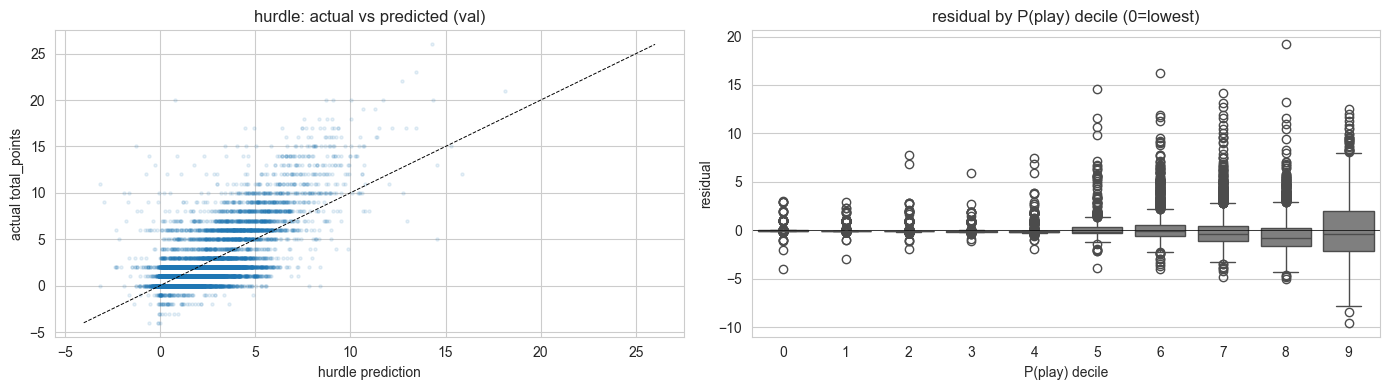

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(pred_hurdle, y_val, alpha=0.1, s=5)
lim = [min(pred_hurdle.min(), y_val.min()), max(pred_hurdle.max(), y_val.max())]
axes[0].plot(lim, lim, "k--", linewidth=0.7)
axes[0].set_xlabel("hurdle prediction")
axes[0].set_ylabel("actual total_points")
axes[0].set_title("hurdle: actual vs predicted (val)")

# Residuals by P(play) decile
decile = pd.qcut(p_play_val, q=10, labels=False, duplicates="drop")
resid = y_val - pred_hurdle
resid_df = pd.DataFrame({"decile": decile, "residual": resid})
sns.boxplot(data=resid_df, x="decile", y="residual", ax=axes[1], color="tab:gray")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("residual by P(play) decile (0=lowest)")
axes[1].set_xlabel("P(play) decile")

plt.tight_layout()
plt.show()

In [12]:
# Per-position MAE: hurdle vs 1.1 flat Ridge — refit Ridge to compare directly
flat_ridge = Ridge(alpha=1.0).fit(X_train_s1, y_train)
flat_pred = flat_ridge.predict(X_val_s1)
flat_metrics = evaluate(y_val, flat_pred, val_positions)

cmp = pd.DataFrame({"flat Ridge (1.1)": flat_metrics, "hurdle (1.2)": hurdle_metrics}).T
cmp["Δ vs flat"] = cmp["mae"] - cmp.loc["flat Ridge (1.1)", "mae"]
print(cmp)

                     r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD  Δ vs flat
flat Ridge (1.1) 0.5989 0.8275  0.6787   0.8451   0.8370   0.8834     0.0000
hurdle (1.2)     0.6386 0.7116  0.4447   0.7424   0.7474   0.7524    -0.1158


## Updated results table

Carry forward the 1.1 reference rows and add the hurdle. xP passthrough included as the FPL-baseline anchor.

In [13]:
results = {
    "xP passthrough": evaluate(y_val, df.loc[val_mask, "xP"].values, val_positions),
    "Ridge flat (1.1, alpha=1)": flat_metrics,
    f"Hurdle ({stage1_name} + Ridge alpha={best_s2_alpha:g})": hurdle_metrics,
}
pd.DataFrame(results).T

,r2,mae,mae_GK,mae_DEF,mae_MID,mae_FWD
xP passthrough,0.5169,0.8129,0.6629,0.8449,0.8271,0.8187
"Ridge flat (1.1, alpha=1)",0.5989,0.8275,0.6787,0.8451,0.8370,0.8834
Hurdle (LR + Ridge alpha=1),0.6386,0.7116,0.4447,0.7424,0.7474,0.7524


## Decisions to record for writeup

The following calls were made in 1.2 and influence downstream interpretation. Capture these in the running decisions log.

1. Hurdle threshold = `played_any` (not `played_60min`). Rationale: structural zero in this target is "no minutes" — getting any minutes guarantees ≥1 appearance point, so y > 0. `played_60min` cuts inside the y > 0 distribution and would force stage 2 to ignore cameo appearances.

2. Stage-1 model selected: see notebook output. If LR: chosen because [SVM didn't justify the subsample caveat / SVM tied within noise]. If SVM-RBF: chosen because [AUC and Brier both improved by margins exceeding tied-within-noise threshold].

3. SVM-RBF trained on a 10,000-row stratified subsample of train. Wall-clock with `probability=True` (Platt scaling adds 5-fold CV) is reported in the notebook. Hyperparameters left at defaults (C=1, gamma='scale') because grid search at this sample size was prohibitive — a bounded comparison, not an optimization.

4. Stage-2 alpha re-tuned on played-only subset. Best alpha logged in cell output. The played-only subset has different variance structure than full train, so reusing 1.1's α=1 was not assumed valid.

5. No threshold on P(play) at inference. Combined prediction is the raw product across all val rows. The residual-by-decile plot would motivate a threshold variant if the lowest P(play) deciles showed systematic bias; check the plot in this notebook before defaulting to the simpler approach.

6. Same feature set as 1.1 (BASE_PREKICKOFF + POSITION + XP + ICT_BLOCK + OTHER_LAGS, no CLUSTER) for both stages. Standardization scalers are separate (stage 1 fit on full train, stage 2 fit on played-only train), but the column set is identical so the comparison to flat Ridge is feature-controlled.